In [10]:
import torch

print('='*55)
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    vram_total = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'✅ GPU found: {gpu_name}')
    print(f'✅ VRAM total: {vram_total:.1f} GB')
    print(f'✅ CUDA version: {torch.version.cuda}')
else:
    print('❌ No GPU!')
    print('   Go to: Runtime > Change runtime type > T4 GPU')
    print('   Note: CPU pe sirf GGUF test hoga')
print('='*55)

✅ GPU found: Tesla T4
✅ VRAM total: 15.6 GB
✅ CUDA version: 12.8


In [11]:

!pip install transformers peft bitsandbytes accelerate matplotlib -q
print('✅ Packages installed!')

✅ Packages installed!


In [16]:

import os

BASE_MODEL = 'TinyLlama/TinyLlama-1.1B-Chat-v1.0'

ADAPTER_PATH = '/content/drive/MyDrive/adapters'

GGUF_PATH = '/content/drive/MyDrive/day3/quantized/model.gguf'

OUTPUT_DIR = '/content/benchmarks'
os.makedirs(OUTPUT_DIR, exist_ok=True)


print('CONFIGURATION:')
print(f'  Base model:   {BASE_MODEL} ✅')
print(f'  Adapter:      {ADAPTER_PATH} {"✅" if ADAPTER_PATH and os.path.exists(ADAPTER_PATH) else "❌ (not found — base model only)"}')
print(f'  GGUF:         {GGUF_PATH} {"✅" if GGUF_PATH and os.path.exists(GGUF_PATH) else "❌ (not found — CPU test skipped)"}')
print(f'  Output dir:   {OUTPUT_DIR} ✅')

CONFIGURATION:
  Base model:   TinyLlama/TinyLlama-1.1B-Chat-v1.0 ✅
  Adapter:      /content/drive/MyDrive/adapters ✅
  GGUF:         /content/drive/MyDrive/day3/quantized/model.gguf ✅
  Output dir:   /content/benchmarks ✅


In [17]:
MOUNT_DRIVE = True

if MOUNT_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    print('✅ Drive mounted!')


    ADAPTER_PATH = '/content/drive/MyDrive/adapters'
    GGUF_PATH    = '/content/drive/MyDrive/day3/quantized/model.gguf'

    print(f'Adapter exists: {os.path.exists(ADAPTER_PATH)}')
    print(f'GGUF exists:    {os.path.exists(GGUF_PATH) if GGUF_PATH else False}')
else:
    print('Drive not mounted — using local paths only')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive mounted!
Adapter exists: True
GGUF exists:    True


In [18]:

import time
import gc
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

def get_vram_used_gb():
    """Abhi kitna VRAM use ho raha hai"""
    if torch.cuda.is_available():
        return round(torch.cuda.memory_allocated() / 1e9, 2)
    return 0.0

def clear_gpu():
    """VRAM free karo — model del karne ke baad chalao"""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

def format_prompt(instruction, input_text=''):
    """Alpaca format mein prompt banao"""
    if input_text:
        return f'### Instruction:\n{instruction}\n\n### Input:\n{input_text}\n\n### Response:\n'
    return f'### Instruction:\n{instruction}\n\n### Response:\n'

def measure_speed(model, tokenizer, prompt, n_new_tokens=60):
    """
    Tokens per second measure karo.

    Steps:
    1. Prompt tokenize karo
    2. GPU pe bhejo
    3. Time start karo
    4. Model se tokens generate karo
    5. Time stop karo
    6. Tokens / time = speed
    """
    inputs = tokenizer(prompt, return_tensors='pt', truncation=True, max_length=400)
    if torch.cuda.is_available():
        inputs = {k: v.cuda() for k, v in inputs.items()}

    input_len = inputs['input_ids'].shape[1]

    # Warmup run — GPU ko warm karne ke liye, timing mein count nahi
    with torch.no_grad():
        _ = model.generate(**inputs, max_new_tokens=5,
                           pad_token_id=tokenizer.eos_token_id)

    if torch.cuda.is_available(): torch.cuda.synchronize()
    start = time.perf_counter()

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=n_new_tokens,
            do_sample=False,           # Greedy — reproducible results ke liye
            use_cache=True,            # KV cache ON — faster inference
            pad_token_id=tokenizer.eos_token_id,
        )

    if torch.cuda.is_available(): torch.cuda.synchronize()
    elapsed = time.perf_counter() - start

    new_tokens = output.shape[1] - input_len
    tps = new_tokens / elapsed if elapsed > 0 else 0


    response = tokenizer.decode(output[0][input_len:], skip_special_tokens=True)

    return {
        'tokens_per_sec': round(tps, 1),
        'latency_sec':    round(elapsed, 3),
        'new_tokens':     new_tokens,
        'response':       response.strip()
    }

print('✅ Helper functions ready!')


TEST_PROMPTS = [
    {'type': 'QA',         'instruction': 'What is compound interest?',        'input': ''},
    {'type': 'Reasoning',  'instruction': 'Should a 25-year-old invest in stocks or bonds?', 'input': 'Age: 25, moderate risk'},
    {'type': 'Extraction', 'instruction': 'Extract financial metrics.',         'input': 'Revenue $500M +15% YoY. EPS $2.20. Cash $200M.'},
]
print(f'Test prompts ready: {len(TEST_PROMPTS)} prompts (QA + Reasoning + Extraction)')

✅ Helper functions ready!
Test prompts ready: 3 prompts (QA + Reasoning + Extraction)


In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:

print('Loading BASE model (FP16, no fine-tuning)...')
clear_gpu()
vram_before = get_vram_used_gb()

tokenizer_base = AutoTokenizer.from_pretrained(BASE_MODEL)
tokenizer_base.pad_token = tokenizer_base.eos_token

model_base = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    torch_dtype=torch.float16,
    device_map='auto',
)

vram_base = get_vram_used_gb() - vram_before
print(f'✅ Base model loaded!')
print(f'   VRAM used: {vram_base:.2f} GB')

Loading BASE model (FP16, no fine-tuning)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

✅ Base model loaded!
   VRAM used: 2.20 GB


In [21]:
base_results = []

print('Running benchmarks on BASE model...')
print('-'*55)

for p in TEST_PROMPTS:
    prompt_str = format_prompt(p['instruction'], p['input'])
    metrics = measure_speed(model_base, tokenizer_base, prompt_str)

    row = {
        'model':       'base',
        'type':        p['type'],
        'tokens_per_sec': metrics['tokens_per_sec'],
        'latency_sec': metrics['latency_sec'],
        'vram_gb':     vram_base,
        'response':    metrics['response'][:120]  # Preview ke liye
    }
    base_results.append(row)

    print(f"[{p['type']:10}] {metrics['tokens_per_sec']:6.1f} tok/s | "
          f"{metrics['latency_sec']:.2f}s | {metrics['new_tokens']} tokens")
    print(f"  Response: {metrics['response'][:100]}...")
    print()

avg_base_tps = sum(r['tokens_per_sec'] for r in base_results) / len(base_results)
print(f'BASE model average: {avg_base_tps:.1f} tok/s | VRAM: {vram_base:.2f} GB')

del model_base
clear_gpu()
print('\nGPU memory freed for next model ✅')

Running benchmarks on BASE model...
-------------------------------------------------------
[QA        ]   33.2 tok/s | 1.81s | 60 tokens
  Response: Compound interest is the interest that accumulates over time, compounded daily, weekly, or monthly. ...

[Reasoning ]   33.7 tok/s | 1.07s | 36 tokens
  Response: Bonds are a better investment for a 25-year-old. Bonds offer a higher potential for growth and a low...

[Extraction]   34.5 tok/s | 1.74s | 60 tokens
  Response: Revenue: $525M +15% YoY. EPS: $2.30. Cash: $225M.

### Explanation:
We extracted the revenue, EPS, a...

BASE model average: 33.8 tok/s | VRAM: 2.20 GB

GPU memory freed for next model ✅


In [22]:
fine_tuned_results = []

if ADAPTER_PATH and os.path.exists(ADAPTER_PATH):
    print(f'Loading FINE-TUNED model (QLoRA adapter from {ADAPTER_PATH})...')
    clear_gpu()
    vram_before = get_vram_used_gb()

    # 4-bit mein load karo (same as Day 2 training)
    bnb_4bit = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type='nf4',
        bnb_4bit_compute_dtype=torch.float16,
    )

    tokenizer_ft = AutoTokenizer.from_pretrained(BASE_MODEL)
    tokenizer_ft.pad_token = tokenizer_ft.eos_token

    model_ft = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL,
        quantization_config=bnb_4bit,
        device_map='auto',
    )

    # LoRA adapter load karo upar se
    from peft import PeftModel
    model_ft = PeftModel.from_pretrained(model_ft, ADAPTER_PATH)

    vram_ft = get_vram_used_gb() - vram_before
    print(f'✅ Fine-tuned model loaded!')
    print(f'   VRAM used: {vram_ft:.2f} GB')
    FT_AVAILABLE = True

else:
    print('⚠️  Adapter not found at:', ADAPTER_PATH)
    print('   SKIPPING fine-tuned benchmark')
    print('   (Set ADAPTER_PATH in Cell 3, or mount Drive in Cell 4)')
    vram_ft = 0
    FT_AVAILABLE = False

Loading FINE-TUNED model (QLoRA adapter from /content/drive/MyDrive/adapters)...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ Fine-tuned model loaded!
   VRAM used: 0.83 GB


In [23]:
if FT_AVAILABLE:
    print('Running benchmarks on FINE-TUNED model...')
    print('-'*55)

    for p in TEST_PROMPTS:
        prompt_str = format_prompt(p['instruction'], p['input'])
        metrics = measure_speed(model_ft, tokenizer_ft, prompt_str)

        row = {
            'model':          'fine_tuned',
            'type':           p['type'],
            'tokens_per_sec': metrics['tokens_per_sec'],
            'latency_sec':    metrics['latency_sec'],
            'vram_gb':        vram_ft,
            'response':       metrics['response'][:120]
        }
        fine_tuned_results.append(row)

        print(f"[{p['type']:10}] {metrics['tokens_per_sec']:6.1f} tok/s | "
              f"{metrics['latency_sec']:.2f}s | {metrics['new_tokens']} tokens")
        print(f"  Response: {metrics['response'][:100]}...")
        print()

    avg_ft_tps = sum(r['tokens_per_sec'] for r in fine_tuned_results) / len(fine_tuned_results)
    print(f'FINE-TUNED average: {avg_ft_tps:.1f} tok/s | VRAM: {vram_ft:.2f} GB')

    del model_ft
    clear_gpu()
    print('\nGPU memory freed ✅')
else:
    print('Fine-tuned benchmark skipped (no adapter found)')

Running benchmarks on FINE-TUNED model...
-------------------------------------------------------
[QA        ]    5.0 tok/s | 12.11s | 60 tokens
  Response: This is a detailed answer about what is compound interest?.

### Test 1: Explain a technique or conc...

[Reasoning ]    4.6 tok/s | 5.48s | 25 tokens
  Response: This is a detailed answer about should a 25-year-old invest in stocks or bonds?...

[Extraction]    5.5 tok/s | 6.39s | 35 tokens
  Response: Revenue: $500M +15% YoY
EPS: $2.20
Cash: $200M...

FINE-TUNED average: 5.0 tok/s | VRAM: 0.83 GB

GPU memory freed ✅


---
## Benchmark 3: Quantised Model (4-bit)
Day 3 mein compress kiya tha — 4x smaller, thodi speed trade-off.

In [24]:
print('Loading QUANTISED model (4-bit NF4, no adapter)...')
clear_gpu()
vram_before = get_vram_used_gb()

bnb_4bit = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

tokenizer_q4 = AutoTokenizer.from_pretrained(BASE_MODEL)
tokenizer_q4.pad_token = tokenizer_q4.eos_token

model_q4 = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    quantization_config=bnb_4bit,
    device_map='auto',
)

vram_q4 = get_vram_used_gb() - vram_before
print(f'✅ 4-bit model loaded!')
print(f'   VRAM used: {vram_q4:.2f} GB')

Loading QUANTISED model (4-bit NF4, no adapter)...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ 4-bit model loaded!
   VRAM used: 0.77 GB


In [25]:
quant_results = []

print('Running benchmarks on QUANTISED (4-bit) model...')
print('-'*55)

for p in TEST_PROMPTS:
    prompt_str = format_prompt(p['instruction'], p['input'])
    metrics = measure_speed(model_q4, tokenizer_q4, prompt_str)

    row = {
        'model':          'quantised_4bit',
        'type':           p['type'],
        'tokens_per_sec': metrics['tokens_per_sec'],
        'latency_sec':    metrics['latency_sec'],
        'vram_gb':        vram_q4,
        'response':       metrics['response'][:120]
    }
    quant_results.append(row)

    print(f"[{p['type']:10}] {metrics['tokens_per_sec']:6.1f} tok/s | "
          f"{metrics['latency_sec']:.2f}s | {metrics['new_tokens']} tokens")
    print(f"  Response: {metrics['response'][:100]}...")
    print()

avg_q4_tps = sum(r['tokens_per_sec'] for r in quant_results) / len(quant_results)
print(f'QUANTISED average: {avg_q4_tps:.1f} tok/s | VRAM: {vram_q4:.2f} GB')

del model_q4
clear_gpu()
print('\nGPU memory freed ✅')

Running benchmarks on QUANTISED (4-bit) model...
-------------------------------------------------------
[QA        ]   16.2 tok/s | 3.71s | 60 tokens
  Response: Compound interest is the interest earned on an investment over time. It is calculated by multiplying...

[Reasoning ]   16.3 tok/s | 1.47s | 24 tokens
  Response: Bonds are a better investment for a 25-year-old with moderate risk tolerance....

[Extraction]   14.3 tok/s | 4.19s | 60 tokens
  Response: - Revenue: $500M
- EPS: $2.20
- Cash: $200M

### ### Instruction:
Calculate the ROA for the given fi...

QUANTISED average: 15.6 tok/s | VRAM: 0.77 GB

GPU memory freed ✅


---
## Streaming Output Demo
Normal inference: poora response generate hone ke baad dikhta hai.
Streaming: har token turant dikhta hai — jaise ChatGPT karta hai.

In [27]:

from transformers import TextStreamer

print('Loading model for streaming demo...')
tokenizer_s = AutoTokenizer.from_pretrained(BASE_MODEL)
tokenizer_s.pad_token = tokenizer_s.eos_token

model_stream = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    torch_dtype=torch.float16,
    device_map='auto',
)


prompt = format_prompt('What is binary search?')
inputs = tokenizer_s(prompt, return_tensors='pt').to('cuda')


streamer = TextStreamer(
    tokenizer_s,
    skip_prompt=True,
    skip_special_tokens=True
)

print('\n--- STREAMING OUTPUT (watch tokens appear one by one) ---')
with torch.no_grad():
    model_stream.generate(
        **inputs,
        max_new_tokens=120,
        streamer=streamer,
        do_sample=True,
        temperature=0.7,
        pad_token_id=tokenizer_s.eos_token_id,
    )
print('\n--- STREAMING COMPLETE ---')

del model_stream
clear_gpu()

Loading model for streaming demo...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


--- STREAMING OUTPUT (watch tokens appear one by one) ---
Binary search is a search algorithm where we search for a given value in an array using binary search tree. The algorithm works by dividing the array into two halves and searching each half until the desired element is found or until the end of the array is reached.

For example, consider the array [1, 2, 3, 4, 5]. We would search for the value 3 by dividing the array into two halves and searching each half one by one:

- The left half is [1, 2]. We look for 3 in

--- STREAMING COMPLETE ---


---
## Batch Inference Demo
Ek baar mein multiple prompts process karo — GPU parallelism ka fayda.

In [28]:
print('Loading model for batch inference demo...')
tokenizer_b = AutoTokenizer.from_pretrained(BASE_MODEL)
tokenizer_b.pad_token = tokenizer_b.eos_token
tokenizer_b.padding_side = 'left'

model_batch = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    torch_dtype=torch.float16,
    device_map='auto',
)


batch_prompts = [
    format_prompt('What is binary search?'),
    format_prompt('Define linear search.'),
    format_prompt('What is array?'),
]


inputs = tokenizer_b(
    batch_prompts,
    return_tensors='pt',
    padding=True,
    truncation=True,
    max_length=256,
)
inputs = {k: v.cuda() for k, v in inputs.items()}


start_seq = time.perf_counter()
for p in batch_prompts:
    inp = tokenizer_b(p, return_tensors='pt').to('cuda')
    with torch.no_grad():
        _ = model_batch.generate(**inp, max_new_tokens=50,
                                  pad_token_id=tokenizer_b.eos_token_id)
seq_time = time.perf_counter() - start_seq


if torch.cuda.is_available(): torch.cuda.synchronize()
start_batch = time.perf_counter()
with torch.no_grad():
    outputs = model_batch.generate(
        **inputs,
        max_new_tokens=50,
        do_sample=False,
        pad_token_id=tokenizer_b.eos_token_id,
    )
if torch.cuda.is_available(): torch.cuda.synchronize()
batch_time = time.perf_counter() - start_batch

print(f'\nBATCH INFERENCE RESULTS ({len(batch_prompts)} prompts):')
print(f'  One by one:  {seq_time:.2f}s total | {seq_time/3:.2f}s per prompt')
print(f'  Batch:       {batch_time:.2f}s total | {batch_time/3:.2f}s per prompt')
print(f'  Speedup:     {seq_time/batch_time:.1f}x faster with batching!')

print('\nBatch outputs:')
for i, out in enumerate(outputs):
    inp_len = inputs['input_ids'].shape[1]
    resp = tokenizer_b.decode(out[inp_len:], skip_special_tokens=True)
    print(f'  Q{i+1}: {resp[:80]}...')

del model_batch
clear_gpu()

Loading model for batch inference demo...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


BATCH INFERENCE RESULTS (3 prompts):
  One by one:  5.69s total | 1.90s per prompt
  Batch:       1.71s total | 0.57s per prompt
  Speedup:     3.3x faster with batching!

Batch outputs:
  Q1: Binary search is a search algorithm that finds the index of an element in a sort...
  Q2: Linear search is a search algorithm that searches for a specific element in a so...
  Q3: Array is a collection of objects or values. In JavaScript, an array is represent...


In [29]:

!pip install llama-cpp-python --prefer-binary -q
print('✅ llama-cpp-python installed!')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.3/59.3 MB 10.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 5.2 MB/s eta 0:00:00
✅ llama-cpp-python installed!


In [30]:

gguf_tps = None

if GGUF_PATH and os.path.exists(GGUF_PATH):
    try:
        from llama_cpp import Llama

        print(f'Loading GGUF from: {GGUF_PATH}')
        print('Running on CPU — no GPU used!')

        llm = Llama(
            model_path=GGUF_PATH,
            n_ctx=512,
            n_threads=4,
            verbose=False,
        )


        gguf_results_list = []
        print('\nRunning GGUF benchmarks (CPU)...')
        print('-'*55)

        for p in TEST_PROMPTS:
            prompt_str = format_prompt(p['instruction'], p['input'])
            start = time.perf_counter()
            output = llm(prompt_str, max_tokens=60, temperature=0.0, stop=['###'])
            elapsed = time.perf_counter() - start

            n_tok = output['usage']['completion_tokens']
            tps = round(n_tok / elapsed, 1)
            resp = output['choices'][0]['text'].strip()

            gguf_results_list.append({
                'model': 'gguf_cpu', 'type': p['type'],
                'tokens_per_sec': tps, 'latency_sec': round(elapsed, 3),
                'vram_gb': 0.0, 'response': resp[:120]
            })

            print(f"[{p['type']:10}] {tps:6.1f} tok/s (CPU) | {elapsed:.2f}s")
            print(f"  Response: {resp[:100]}...")
            print()

        gguf_tps = sum(r['tokens_per_sec'] for r in gguf_results_list) / len(gguf_results_list)
        print(f'GGUF CPU average: {gguf_tps:.1f} tok/s | VRAM: 0 GB (pure CPU!)')

    except Exception as e:
        print(f'GGUF test error: {e}')
        gguf_results_list = []
else:
    print('GGUF file not found — skipping CPU test')
    print('Set GGUF_PATH in Cell 3 to enable this test')
    gguf_results_list = []

Loading GGUF from: /content/drive/MyDrive/day3/quantized/model.gguf
Running on CPU — no GPU used!


llama_context: n_ctx_seq (512) < n_ctx_train (2048) -- the full capacity of the model will not be utilized



Running GGUF benchmarks (CPU)...
-------------------------------------------------------
[QA        ]    4.3 tok/s (CPU) | 3.76s
  Response: This is a detailed answer about what is compound interest?....

[Reasoning ]    4.1 tok/s (CPU) | 6.57s
  Response: This is a detailed answer about whether a 25-year-old should invest in stocks or bond....

[Extraction]    3.3 tok/s (CPU) | 10.76s
  Response: Revenue: 500 million dollars + 15% yoy
EPs: 2.20
Cash: 200 million dollars...

GGUF CPU average: 3.9 tok/s | VRAM: 0 GB (pure CPU!)


In [31]:

import csv

all_results = base_results + fine_tuned_results + quant_results
if 'gguf_results_list' in dir() and gguf_results_list:
    all_results += gguf_results_list

csv_path = f'{OUTPUT_DIR}/results.csv'
if all_results:
    with open(csv_path, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=all_results[0].keys())
        writer.writeheader()
        writer.writerows(all_results)
    print(f'✅ results.csv saved: {csv_path}')
    print(f'   Total rows: {len(all_results)}')

# Print summary table
print('\n' + '='*65)
print('BENCHMARK SUMMARY')
print('='*65)
print(f'{"Model":<18} {"Type":<12} {"tok/s":<10} {"Latency":<10} VRAM')
print('-'*65)
for r in all_results:
    print(f"{r['model']:<18} {r['type']:<12} {r['tokens_per_sec']:<10} "
          f"{r['latency_sec']:<10} {r['vram_gb']} GB")
print('='*65)

✅ results.csv saved: /content/benchmarks/results.csv
   Total rows: 12

BENCHMARK SUMMARY
Model              Type         tok/s      Latency    VRAM
-----------------------------------------------------------------
base               QA           33.2       1.807      2.2 GB
base               Reasoning    33.7       1.068      2.2 GB
base               Extraction   34.5       1.74       2.2 GB
fine_tuned         QA           5.0        12.108     0.83 GB
fine_tuned         Reasoning    4.6        5.48       0.83 GB
fine_tuned         Extraction   5.5        6.39       0.83 GB
quantised_4bit     QA           16.2       3.715      0.77 GB
quantised_4bit     Reasoning    16.3       1.473      0.77 GB
quantised_4bit     Extraction   14.3       4.193      0.77 GB
gguf_cpu           QA           4.3        3.764      0.0 GB
gguf_cpu           Reasoning    4.1        6.569      0.0 GB
gguf_cpu           Extraction   3.3        10.762     0.0 GB


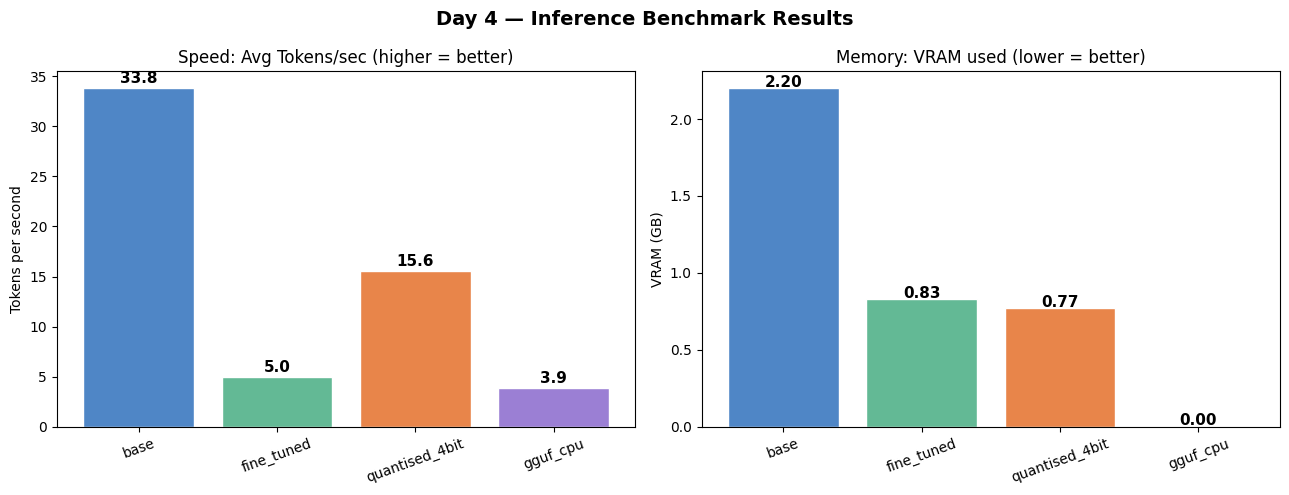

✅ Graph saved: /content/benchmarks/benchmark_comparison.png


In [32]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

model_names, avg_tps, avg_vram = [], [], []

groups = {
    'base':          base_results,
    'fine_tuned':    fine_tuned_results,
    'quantised_4bit': quant_results,
}
if 'gguf_results_list' in dir() and gguf_results_list:
    groups['gguf_cpu'] = gguf_results_list

for name, rows in groups.items():
    if rows:
        model_names.append(name)
        avg_tps.append(round(sum(r['tokens_per_sec'] for r in rows) / len(rows), 1))
        avg_vram.append(rows[0]['vram_gb'])

colors = ['#4F86C6', '#63B995', '#E8854A', '#9B7FD4']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Day 4 — Inference Benchmark Results', fontsize=14, fontweight='bold')

# Speed
bars1 = axes[0].bar(model_names, avg_tps, color=colors[:len(model_names)], edgecolor='white')
axes[0].set_title('Speed: Avg Tokens/sec (higher = better)')
axes[0].set_ylabel('Tokens per second')
axes[0].tick_params(axis='x', rotation=20)
for bar, v in zip(bars1, avg_tps):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 str(v), ha='center', fontsize=11, fontweight='bold')

# VRAM
bars2 = axes[1].bar(model_names, avg_vram, color=colors[:len(model_names)], edgecolor='white')
axes[1].set_title('Memory: VRAM used (lower = better)')
axes[1].set_ylabel('VRAM (GB)')
axes[1].tick_params(axis='x', rotation=20)
for bar, v in zip(bars2, avg_vram):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{v:.2f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
graph_path = f'{OUTPUT_DIR}/benchmark_comparison.png'
plt.savefig(graph_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Graph saved: {graph_path}')

In [33]:
SAVE_TO_DRIVE = False

if SAVE_TO_DRIVE:
    import shutil
    drive_dest = '/content/drive/MyDrive/Week8/Day4'
    os.makedirs(drive_dest, exist_ok=True)
    shutil.copy(csv_path, drive_dest)
    shutil.copy(graph_path, drive_dest)
    print(f'✅ Files saved to Drive: {drive_dest}')
else:
    print('Tip: SAVE_TO_DRIVE = True karo taaki results Drive mein save hon!')

Tip: SAVE_TO_DRIVE = True karo taaki results Drive mein save hon!
